# 01 — Machine Learning Basics

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 1 of 20**

This notebook builds the vocabulary and mental model for everything that follows in Sprint 7.
Nothing here is implemented "because scikit-learn has a function for it" — the goal is to understand
*why* Machine Learning exists as a discipline, *how* it differs from the programming you already know,
and what each term (feature, target, model, parameter, hyperparameter...) actually refers to before we
touch a single algorithm.

**Dataset note:** this notebook is concept-first, so the small code cells use toy/synthetic data or the
built-in `California Housing` and `digits` datasets purely to *illustrate* an idea. The real project
dataset (continuing from Sprint 6) is used starting from Notebook 4 onward.


## 1. What is Machine Learning?

**Definition.** Machine Learning is a way of building software that *learns a mapping from data*
instead of being told the mapping by a programmer. Formally (Tom Mitchell's definition, 1997):

> A computer program is said to learn from experience **E** with respect to some task **T** and
> performance measure **P**, if its performance at T, as measured by P, improves with experience E.

**Why is it required?**
Some problems don't have a clean, hand-codable rule. Nobody can write `if pixel[12][14] > 200 and ...`
rules that reliably recognize a handwritten "7" across thousands of different handwriting styles — but
if you show a learning algorithm thousands of labeled examples, it can discover the pattern itself.
ML is required whenever:
- The rules are too complex or too numerous to hand-code (image recognition, speech, fraud patterns).
- The rules change over time and the system needs to adapt (spam evolves, so must the spam filter).
- We have lots of data but no explicit theory connecting inputs to outputs (recommendation systems).
- A human expert can *do* the task well but can't *articulate* precisely how (medical diagnosis from
  scans).

**How does it work, at a high level?**
1. Collect examples of the task being done (data).
2. Choose a model — a family of functions with adjustable internal numbers (parameters).
3. Define a performance measure (a cost/loss function) that scores how wrong the model's predictions are.
4. Search for the parameter values that minimize that loss on the training examples (this search is
   "training" / "fitting").
5. Check that the learned mapping generalizes to *new*, unseen examples (this is the entire point —
   memorizing the training data is not learning).

**What problem does it solve?**
It replaces *hand-engineered rules* with *rules inferred from data*, and it lets a system improve as
more data becomes available, without a human rewriting the logic every time.

**Assumptions ML relies on**
- The training data is representative of the data the model will see in production (same distribution).
- There is actually a learnable statistical relationship between the inputs and the output — ML cannot
  invent structure that isn't there.
- Enough data exists (relative to the problem's complexity) to distinguish real patterns from noise.
- The examples are, for supervised learning, correctly labeled (garbage labels → garbage model).

**When should it be used?**
- The problem is too complex for explicit rules, or the rules keep changing.
- You have a reasonable volume of relevant, labeled (or at least structured) data.
- Some tolerance for imperfect predictions is acceptable (ML is probabilistic, not exact).

**When should it *not* be used?**
- A simple deterministic rule already solves the problem correctly (don't train a model to check if a
  number is even).
- You need 100% explainable, auditable, guaranteed-correct logic (e.g., tax calculation) — use
  traditional programming.
- You have almost no data and no way to get more.
- The cost of an occasional wrong prediction is unacceptable and there's no way to add human review.


In [1]:
# A tiny illustration: "is this number even?" does NOT need ML — a rule is exact and free.
def is_even_rule_based(n):
    return n % 2 == 0

print([is_even_rule_based(n) for n in range(10)])
# There is no ambiguity, no noise, and no pattern to "discover" here — ML would be the wrong tool.


[True, False, True, False, True, False, True, False, True, False]


## 2. Traditional Programming vs Machine Learning

| | Traditional Programming | Machine Learning |
|---|---|---|
| Input to the system | Rules (code) + Data | Data + (labels, for supervised learning) |
| Output of the system | Answers | Rules (a trained model) |
| Who writes the logic | The programmer, explicitly | The algorithm, by fitting parameters to data |
| Adapts automatically? | No — someone edits the code | Yes — retrain on new data |
| Best suited for | Well-defined, rule-expressible problems | Pattern-heavy, hard-to-articulate problems |

The key mental flip: in traditional programming you supply **rules + data → get answers**.
In Machine Learning you supply **data + answers (examples) → get rules** (a model), and that model is
then used to produce new answers for new data.


In [2]:
# Traditional programming: rules + data -> answers
def celsius_to_fahrenheit(c):
    return c * 9/5 + 32

data = [0, 20, 37, 100]
answers = [celsius_to_fahrenheit(c) for c in data]
print("Traditional:", list(zip(data, answers)))

# Machine Learning flavor of the SAME relationship: data + answers -> rule (learned, not hand-written)
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([0, 10, 20, 30, 37, 100]).reshape(-1, 1)   # celsius (feature)
y = np.array([32, 50, 68, 86, 98.6, 212])                 # fahrenheit (target/answers)

model = LinearRegression()
model.fit(X, y)  # the algorithm DISCOVERS the rule from examples

print(f"\nML discovered: F = {model.coef_[0]:.2f} * C + {model.intercept_:.2f}")
print("(true rule is F = 1.80 * C + 32.00 -- notice the model reconstructed it purely from examples)")


Traditional: [(0, 32.0), (20, 68.0), (37, 98.6), (100, 212.0)]



ML discovered: F = 1.80 * C + 32.00
(true rule is F = 1.80 * C + 32.00 -- notice the model reconstructed it purely from examples)


## 3. AI vs ML vs Deep Learning

These three terms are nested, not interchangeable:

- **Artificial Intelligence (AI)** — the broadest field: building systems that perform tasks we
  associate with intelligence (reasoning, planning, perception, language, decision-making). This
  includes hand-coded rule engines, search algorithms, and expert systems — none of which need to
  "learn" from data.
- **Machine Learning (ML)** — a *subset* of AI where the system improves its performance by learning
  patterns from data, rather than following only hand-written rules.
- **Deep Learning (DL)** — a *subset* of ML that uses multi-layered artificial neural networks,
  particularly effective when there is a large amount of data and the raw input is unstructured
  (images, audio, raw text) so that hand-crafted features aren't needed — the network learns its own
  feature representations layer by layer.

So: **every Deep Learning system is Machine Learning, every Machine Learning system is AI, but not
every AI system uses ML, and not every ML system is Deep Learning** (e.g., Linear Regression and
Decision Trees are ML but not DL).


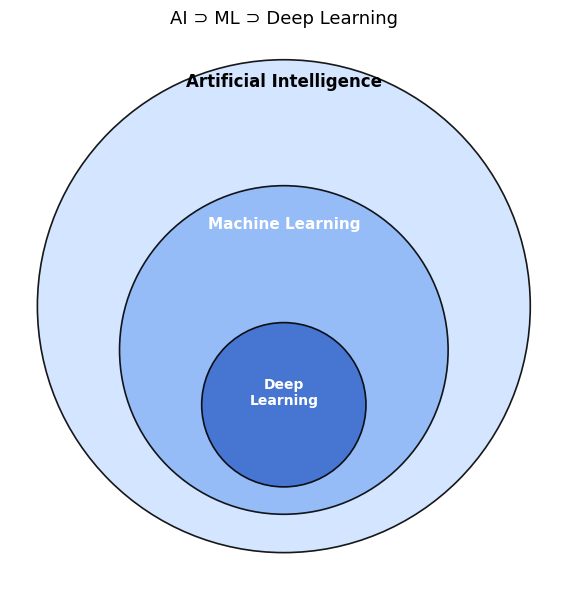

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
circles = [
    (0.5, 0.5, 0.45, "#cfe3ff", "Artificial Intelligence\n(rule engines, search, planning, ML...)"),
    (0.5, 0.42, 0.30, "#8fb8f6", "Machine Learning\n(learns from data)"),
    (0.5, 0.32, 0.15, "#3f6fce", "Deep\nLearning"),
]
for x, y, r, color, _ in circles:
    ax.add_patch(plt.Circle((x, y), r, color=color, ec="black", lw=1.2, alpha=0.9))

ax.text(0.5, 0.90, "Artificial Intelligence", ha="center", fontsize=12, fontweight="bold")
ax.text(0.5, 0.64, "Machine Learning", ha="center", fontsize=11, fontweight="bold", color="white")
ax.text(0.5, 0.32, "Deep\nLearning", ha="center", fontsize=10, fontweight="bold", color="white")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("AI ⊃ ML ⊃ Deep Learning", fontsize=13)
plt.tight_layout()
plt.savefig("ai_ml_dl.png", dpi=120)
plt.show()


## 4. The Four Learning Paradigms

### 4.1 Supervised Learning
The training data includes **both inputs and the correct output (label)** for each example. The
algorithm learns a mapping `f(X) -> y` by comparing its predictions to the known correct answers and
adjusting itself to reduce the error. This is the most common paradigm in industry because labeled
data (even if expensive to obtain) gives the clearest training signal.
- Sub-types: **Classification** (label is a category) and **Regression** (label is a continuous number).
- Examples: spam detection, house price prediction, digit recognition, credit default prediction.

### 4.2 Unsupervised Learning
The training data has **inputs only — no labels**. The algorithm must find structure (groups,
compressed representations, associations) in the data on its own.
- Sub-types: **Clustering** (group similar points), **Dimensionality Reduction** (compress features
  while preserving structure), **Association Rule Learning** (find "if A then B" patterns).
- Examples: customer segmentation, anomaly detection, topic discovery, compressing images.

### 4.3 Semi-Supervised Learning
A **small amount of labeled data** is combined with a **large amount of unlabeled data**. Labeling is
often expensive (needs a human expert), while unlabeled data is cheap and abundant, so the algorithm
uses the unlabeled data to understand the overall data distribution/structure and the labeled data to
anchor that structure to actual categories.
- Examples: Google Photos clustering faces across all your photos (unsupervised) and then you label one
  photo per person (a handful of labels) so it can name everyone else's occurrences.

### 4.4 Reinforcement Learning
There is no fixed dataset of "correct answers" at all. An **agent** interacts with an **environment**,
takes **actions**, and receives **rewards or penalties**. It learns a **policy** (a strategy of which
action to take in which state) that maximizes cumulative reward over time, through trial and error.
- Examples: game-playing agents (AlphaGo), robotics control, resource allocation, recommendation systems
  optimized for long-term engagement.


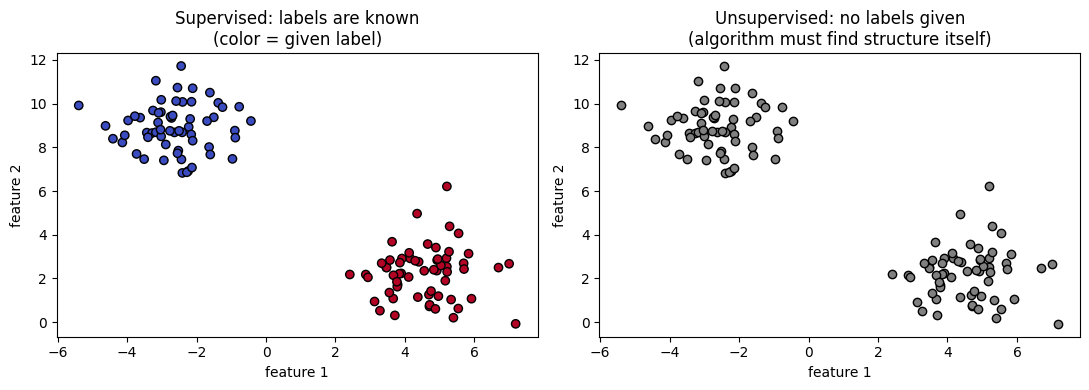

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Supervised (classification): points ARE labeled -> model learns the boundary
X, y = make_blobs(n_samples=120, centers=2, cluster_std=1.1, random_state=42)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
axes[0].set_title("Supervised: labels are known\n(color = given label)")

# --- Unsupervised (clustering): points are UNlabeled -> algorithm has to discover groups
axes[1].scatter(X[:, 0], X[:, 1], c="gray", edgecolor="k")
axes[1].set_title("Unsupervised: no labels given\n(algorithm must find structure itself)")

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.savefig("supervised_vs_unsupervised.png", dpi=120)
plt.show()


## 5. Classification vs Regression vs Clustering

- **Classification** (supervised): predict a **discrete category**. "Is this email spam or not?",
  "which digit is this (0-9)?". Output is one of a fixed set of classes.
- **Regression** (supervised): predict a **continuous number**. "What will this house sell for?",
  "what will tomorrow's temperature be?". Output is any real number (within a range).
- **Clustering** (unsupervised): **group** data points by similarity, with no predefined categories.
  "Segment customers into behaviorally similar groups" — the algorithm decides what the groups even are.

A quick way to tell classification from regression: **if you can meaningfully compute an average of the
outputs and get something sensible, it's regression; if averaging the outputs is meaningless, it's
classification.** (Average of "$300k, $450k" = $375k, meaningful. Average of "cat, dog" = nonsense.)


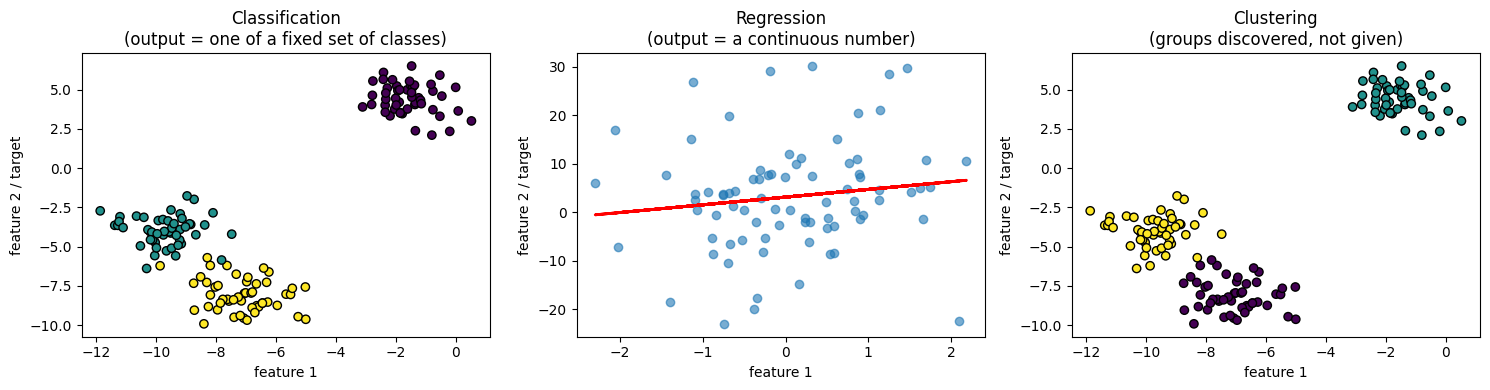

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_regression
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classification: discrete decision regions
Xc, yc = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=1)
axes[0].scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="viridis", edgecolor="k")
axes[0].set_title("Classification\n(output = one of a fixed set of classes)")

# Regression: continuous line fit
Xr, yr = make_regression(n_samples=80, n_features=1, noise=12, random_state=1)
reg = LinearRegression().fit(Xr, yr)
axes[1].scatter(Xr, yr, alpha=0.6)
axes[1].plot(Xr, reg.predict(Xr), color="red", linewidth=2)
axes[1].set_title("Regression\n(output = a continuous number)")

# Clustering: unlabeled -> algorithm assigns groups
Xu, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=1)
labels = KMeans(n_clusters=3, n_init=10, random_state=1).fit_predict(Xu)
axes[2].scatter(Xu[:, 0], Xu[:, 1], c=labels, cmap="viridis", edgecolor="k")
axes[2].set_title("Clustering\n(groups discovered, not given)")

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2 / target")
plt.tight_layout()
plt.savefig("classification_regression_clustering.png", dpi=120)
plt.show()


## 6. Core Vocabulary

| Term | Meaning |
|---|---|
| **Feature** | An individual measurable input variable (a column of X). E.g. `square_footage`, `num_bedrooms`. |
| **Target** | The output variable the model is trying to predict (y). Also called the *label* in classification. |
| **Training** | The process of adjusting a model's parameters so its predictions match the targets as closely as possible on the training data. |
| **Prediction** | The model's output for a new, previously unseen input. |
| **Model** | The mathematical object (with its learned parameters) that maps features to a prediction. |
| **Parameters** | Internal values the model *learns* automatically during training (e.g., the slope and intercept of a line). You never set these by hand. |
| **Hyperparameters** | Settings **you** choose *before* training that control how the training process behaves (e.g., `k` in KNN, `max_depth` in a Decision Tree, the learning rate). They are tuned via experimentation/validation, not learned from data directly. |

The clearest way to keep parameters vs hyperparameters straight: **if fit() learns it, it's a
parameter; if you pass it into the constructor before fit() is even called, it's a hyperparameter.**


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Toy dataset: 1 feature (X), 1 target (y)
X = np.array([[1], [2], [3], [4], [5]])   # feature
y = np.array([3, 5, 7, 9, 11])            # target  (true rule: y = 2x + 1)

# --- Linear Regression: PARAMETERS are learned automatically by fit()
lr = LinearRegression()
lr.fit(X, y)
print("Learned PARAMETERS (found by training, not set by us):")
print(f"  coefficient (slope)   = {lr.coef_[0]:.2f}")
print(f"  intercept              = {lr.intercept_:.2f}")

# --- KNN: n_neighbors is a HYPERPARAMETER -- WE choose it before training, fit() does not learn it
knn = KNeighborsRegressor(n_neighbors=2)   # <- hyperparameter, chosen by us up front
knn.fit(X, y)
print(f"\nHYPERPARAMETER we chose ourselves: n_neighbors = {knn.n_neighbors}")
print(f"Prediction for a new input X=[[6]]: {knn.predict([[6]])[0]:.2f}")


Learned PARAMETERS (found by training, not set by us):
  coefficient (slope)   = 2.00
  intercept              = 1.00

HYPERPARAMETER we chose ourselves: n_neighbors = 2
Prediction for a new input X=[[6]]: 10.00


## 7. The Complete Machine Learning Workflow (preview)

This is the big picture — every stage below gets its own deep dive in **Notebook 2 (`02_ML_Workflow.ipynb`)**.
For now, just get the sequence into your head:

```
Business Problem
      │
      ▼
Data Collection  ──►  Data Understanding / EDA  ──►  Data Preprocessing
      │                                                     │
      ▼                                                     ▼
Feature Engineering  ──►  Train / Test Split  ──►  Model Selection
      │                                                     │
      ▼                                                     ▼
Model Training  ──►  Prediction  ──►  Evaluation  ──►  Hyperparameter Tuning
                                                              │
                                                              ▼
                                              Final Model Selection ──► Deployment ──► Monitoring
```

Notice **Data → Features → Algorithm → Training → Prediction → Evaluation → Improvement** is the loop
this entire sprint is structured around, and it is *iterative* — evaluation routinely sends you back to
feature engineering or model selection, not straight to deployment.


## 8. Summary — Key Takeaways

- ML lets software learn a mapping from data instead of being told the mapping explicitly — use it when
  rules are too complex/numerous/changing to hand-code, and there is enough representative data.
- AI ⊃ ML ⊃ Deep Learning: DL is a data-hungry, neural-network-based subset of ML, which is itself a
  subset of the broader field of AI.
- Supervised learning needs labels and learns `X -> y`; unsupervised learning has no labels and finds
  structure; semi-supervised blends a little labeled data with a lot of unlabeled data; reinforcement
  learning learns through reward/penalty feedback from actions in an environment, with no fixed dataset
  at all.
- Classification predicts categories, regression predicts continuous numbers, clustering discovers
  groups without being told what the groups are.
- Feature = input column, target = what you're predicting, model = the trained mapping, parameters =
  learned automatically by `fit()`, hyperparameters = chosen by you *before* `fit()` runs.


## 9. Try It Yourself (no solutions given — this is for you to work through)

Work through these before moving to Notebook 2. They're deliberately not solved here — the point is to
reason it out yourself; ask if you get stuck on a specific one.

1. For each of the following, state whether it is **Classification**, **Regression**, or **Clustering**,
   and justify your answer using the "can you meaningfully average the outputs?" test from Section 5:
   - Predicting a customer's monthly churn risk score (0.0 to 1.0)
   - Predicting whether a bank transaction is fraudulent or not
   - Grouping news articles into topics without being told the topics in advance
   - Predicting tomorrow's rainfall in millimetres
2. Pick one real problem from your own domain (agriculture / farming is a good one, given your coconut
   farm background) and describe: what would the features be, what would the target be, and would you
   frame it as supervised or unsupervised? Would it be regression or classification?
3. In the KNN example in Section 6, change `n_neighbors` to 1 and to 4 and re-run. What changes in the
   prediction, and why does changing a *hyperparameter* (not a parameter) change the outcome?
4. Name one AI system that does NOT use Machine Learning at all (hint: think of rule-based systems, not
   anything that "learns").
